# RetailSense AI
## Notebook 01 . Business Understanding & Project Overview
---
**Organization:** Celebal Technologies &nbsp;|&nbsp; **Intern:** Ayush Choudhary  
**Domain:** Data Science . Time Series Forecasting . Inventory Intelligence  
**Dataset:** [Kaggle Store-Item Demand Forecasting](https://www.kaggle.com/competitions/demand-forecasting-kernels-only)
 -- 913 K records . 10 Stores . 50 Items . 5 Years (2013-2017)

---

### Problem Statement
Retail demand forecasting is a **$1.1T problem** (McKinsey, 2023). Inaccurate demand
prediction leads to:
- **Overstocking**: ~$470B/year in excess inventory globally (IHL Group)
- **Stockouts**: ~$630B/year in lost revenue globally
- **Waste**: 8% of perishable goods discarded annually

### Objective
Build a **production-grade, explainable multi-horizon demand forecasting platform**
that replaces naive heuristics with machine learning to:

1. Forecast daily sales at the **store-item level** (500 time series)
2. Reduce MAE below the **7.0 units/day business target**
3. Translate model accuracy into **dollar-value business impact**
4. Provide **automated supply chain recommendations** (Safety Stock, Reorder Point)


In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    'figure.figsize'    : (12, 5),
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'font.size'         : 11,
})


### End-to-End Project Pipeline

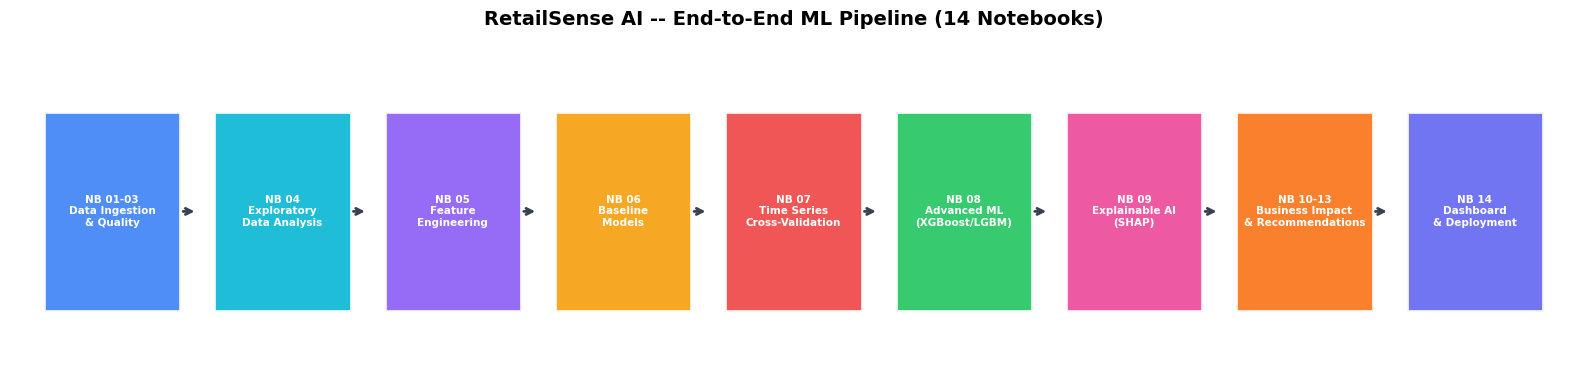

In [2]:
# ── Visual: End-to-End ML Pipeline Architecture ──────────────────
stages = [
    ('01-03', 'Data Ingestion\n& Quality', '#3b82f6'),
    ('04',    'Exploratory\nData Analysis', '#06b6d4'),
    ('05',    'Feature\nEngineering', '#8b5cf6'),
    ('06',    'Baseline\nModels', '#f59e0b'),
    ('07',    'Time Series\nCross-Validation', '#ef4444'),
    ('08',    'Advanced ML\n(XGBoost/LGBM)', '#22c55e'),
    ('09',    'Explainable AI\n(SHAP)', '#ec4899'),
    ('10-13', 'Business Impact\n& Recommendations', '#f97316'),
    ('14',    'Dashboard\n& Deployment', '#6366f1'),
]

fig, ax = plt.subplots(figsize=(16, 4))
n = len(stages)
for i, (nb_id, label, color) in enumerate(stages):
    x = i * 1.5
    rect = plt.Rectangle((x, 0.2), 1.2, 0.6, facecolor=color, edgecolor='white',
                           linewidth=2, zorder=3, alpha=0.9)
    ax.add_patch(rect)
    ax.text(x + 0.6, 0.5, f'NB {nb_id}\n{label}', ha='center', va='center',
            fontsize=7.5, color='white', fontweight='bold', zorder=4)
    if i < n - 1:
        ax.annotate('', xy=(x+1.35, 0.5), xytext=(x+1.2, 0.5),
                     arrowprops=dict(arrowstyle='->', color='#374151', lw=2), zorder=5)

ax.set_xlim(-0.3, n*1.5); ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('RetailSense AI -- End-to-End ML Pipeline (14 Notebooks)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout(); plt.show()


### Dataset Overview

| Attribute | Value |
|:----------|:------|
| **Source** | Kaggle Store-Item Demand Forecasting Competition |
| **Records** | 913,000 daily observations |
| **Time Span** | 2013-01-01 to 2017-12-31 (5 years) |
| **Stores** | 10 retail locations |
| **Items** | 50 unique SKUs per store |
| **Target** | `sales` (integer, daily unit sales) |
| **Features** | `date`, `store`, `item`, `sales` |

### Success Criteria

| KPI | Target | Rationale |
|:----|:-------|:----------|
| MAE | < 7.0 units/day | Business-critical threshold for inventory planning |
| MAPE | < 15% | Industry standard for retail forecasting |
| Model Stability | CV std(MAE) < 1.0 | Consistent performance across time folds |
| Business ROI | > 200% over 5 years | Justifies platform investment |
